In [ ]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
import numpy as np
import pandas as pd
import cupy as cp
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from imblearn.over_sampling import SMOTE
from cuml.ensemble import RandomForestClassifier

In [ ]:
# =========================================================
# Load Dataset
# =========================================================
df = pd.read_csv("creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================================================
# Global Configurations
# =========================================================
RANDOM_STATE = 42
KFOLD_SPLITS = 5
RF_N_ITER = 10
CUSTOM_THRESH = 0.3

# Hyperparameter search spaces
RF_PARAM_SPACE = {
    "n_estimators": [100, 200, 500],
    "max_depth": [6, 10, 12],
    "n_bins": [64, 128],
    "bootstrap": [False, True],
    "split_criterion": ["gini", "entropy"],
}

# Expanded GPU space
GRF_PARAM_SPACE = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [8, 12, 16, 20, 24],
    "split_criterion": ["gini", "entropy"],
    "n_bins": [64, 128, 256],
    "bootstrap": [True, False]
}

# Set seeds
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [ ]:
# =========================================================
# Cross-Validation (ROC-AUC)
# =========================================================
def cross_validate_gpu_rf(model_builder, X, y, kfold):
    """
    Performs K-fold cross-validation for cuML Random Forest
    and returns the mean and standard deviation of ROC-AUC scores.
    """
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

        model = model_builder()
        model.fit(Xtr, ytr)

        y_prob = model.predict_proba(Xval)
        if isinstance(y_prob, cp.ndarray):
            y_prob = y_prob.get()
        if hasattr(y_prob, "to_numpy"):
            y_prob = y_prob.to_numpy()
        if y_prob.ndim == 2:
            y_prob = y_prob[:, 1]

        auc_score = roc_auc_score(yval, y_prob)
        print(f"    Fold {fold}: ROC-AUC = {auc_score:.4f}")
        scores.append(auc_score)

    return np.mean(scores), np.std(scores)

# =========================================================
# Random Search for cuML GPU Random Forest
# =========================================================
def random_search_gpu_rf(X, y, kfold, n_iter=RF_N_ITER, param_space=GRF_PARAM_SPACE):
    """
    Randomly searches hyperparameters for the cuML Random Forest model.
    Returns the best trained model and parameters.
    """
    best_score, best_params, best_builder = -1, None, None

    print("\n============================================================")
    print("GPU RANDOM FOREST (cuML) RANDOM SEARCH STARTED")
    print("============================================================\n")

    for i in range(n_iter):
        params = {
            "n_estimators": random.choice(param_space["n_estimators"]),
            "max_depth": random.choice(param_space["max_depth"]),
            "n_bins": random.choice(param_space["n_bins"]),
            "bootstrap": random.choice(param_space["bootstrap"]),
            "split_criterion": random.choice(param_space["split_criterion"]),
        }

        print(f"  Iter {i+1}/{n_iter}: {params}")

        def builder(params=params):
            return RandomForestClassifier(
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                n_bins=params["n_bins"],
                bootstrap=params["bootstrap"],
                split_criterion=params["split_criterion"],
                random_state=RANDOM_STATE,
                n_streams=8
            )

        mean_cv, std_cv = cross_validate_gpu_rf(builder, X, y, kfold)
        print(f"    CV ROC-AUC: {mean_cv:.4f} ± {std_cv:.4f}\n")

        if mean_cv > best_score:
            best_score, best_params, best_builder = mean_cv, params.copy(), builder

    print(f"Best Params Found: {best_params}, ROC-AUC={best_score:.4f}")

    final_model = best_builder()
    final_model.fit(X, y)
    return final_model, best_params

# =========================================================
# Evaluation Function (Enhanced)
# =========================================================
def evaluate_gpu_rf(model, X_test, y_test, label="Model", threshold=0.3):
    """
    Evaluates a trained GPU Random Forest model with:
      - Confusion Matrix (heatmap)
      - ROC Curve
      - Precision–Recall Curve
      - F1 vs Threshold curve
    Returns key metrics including ROC-AUC, PR-AUC, and best threshold by F1.
    """
    # Get predicted probabilities (convert from GPU arrays if needed)
    y_prob = model.predict_proba(X_test)
    if isinstance(y_prob, cp.ndarray):
        y_prob = y_prob.get()
    if hasattr(y_prob, "to_numpy"):
        y_prob = y_prob.to_numpy()
    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]

    # Binarize predictions using threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Compute metrics
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else threshold

    print(f"\n{label} — Evaluation Metrics")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"PR-AUC Score:  {pr_auc:.4f}")
    print(f"Optimal Threshold (by F1): {best_thresh:.3f}  (F1={np.max(f1):.3f})")

    # -------------------------------------
    # Confusion Matrix (heatmap)
    # -------------------------------------
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()

    # -------------------------------------
    # ROC Curve
    # -------------------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------
    # Precision–Recall Curve
    # -------------------------------------
    plt.figure(figsize=(6, 5))
    plt.plot(rec, prec, color="orange", label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------
    # F1 vs Threshold Curve
    # -------------------------------------
    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, f1[:-1], color="green")
    plt.axvline(best_thresh, color="red", linestyle="--", label=f"Best = {best_thresh:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title(f"F1 Score vs Threshold — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return metrics
    return {
        "model": label,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": best_thresh
    }

# =========================================================
# Training Function with Balancing Methods
# =========================================================
def train_gpu_rf_balance(X_train, y_train, X_test, y_test,
                         balance_method="none", threshold=0.3):
    """
    Trains GPU Random Forest (cuML) with various balancing methods:
    - none
    - class_weight
    - smote
    - smote_class_weight
    Each run performs random search and prints best parameters.
    """
    print("==============================================")
    print(f"GPU RANDOM FOREST TRAINING STARTED ({balance_method.upper()})")
    print("==============================================")

    kfold = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # Apply balancing
    if balance_method == "smote":
        print("Applying SMOTE balancing...")
        sm = SMOTE(random_state=RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        sample_weight = None
    elif balance_method == "class_weight":
        print("Applying manual class weights...")
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        w_pos = neg / max(pos, 1)
        sample_weight = np.where(y_train == 1, w_pos, 1)
    elif balance_method == "smote_class_weight":
        print("Applying SMOTE + Class Weight hybrid...")
        sm = SMOTE(random_state=RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())
        w_pos = neg / max(pos, 1)
        sample_weight = np.where(y_train == 1, w_pos, 1)
    else:
        print("No balancing applied.")
        sample_weight = None

    # Run random search
    model, best_params = random_search_gpu_rf(X_train, y_train, kfold, param_space=GRF_PARAM_SPACE)
    print(f"\nBest Parameters for {balance_method.upper()}: {best_params}")

    # Fit with or without sample weights
    if sample_weight is not None:
        try:
            model.fit(X_train, y_train, sample_weight=sample_weight)
        except TypeError:
            print("sample_weight not supported by cuML — fitting without weights.")
            model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)

    # Evaluate model
    metrics = evaluate_gpu_rf(model, X_test, y_test,
                              label=f"Random Forest ({balance_method.upper()})",
                              threshold=threshold)
    metrics["best_params"] = best_params
    return model, metrics

GPU RANDOM FOREST TRAINING STARTED (NONE)
No balancing applied.

GPU RANDOM FOREST (cuML) RANDOM SEARCH STARTED

  Iter 1/10: {'n_estimators': 200, 'max_depth': 8, 'n_bins': 256, 'bootstrap': False, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9868
    Fold 2: ROC-AUC = 0.9720
    Fold 3: ROC-AUC = 0.9776
    Fold 4: ROC-AUC = 0.9890
    Fold 5: ROC-AUC = 0.9729
    CV ROC-AUC: 0.9797 ± 0.0070

  Iter 2/10: {'n_estimators': 400, 'max_depth': 12, 'n_bins': 256, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9866
    Fold 2: ROC-AUC = 0.9805
    Fold 3: ROC-AUC = 0.9736
    Fold 4: ROC-AUC = 0.9900
    Fold 5: ROC-AUC = 0.9761
    CV ROC-AUC: 0.9814 ± 0.0062

  Iter 3/10: {'n_estimators': 1000, 'max_depth': 20, 'n_bins': 64, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9844
    Fold 2: ROC-AUC = 0.9619
    Fold 3: ROC-AUC = 0.9418
    Fold 4: ROC-AUC = 0.9836
    Fold 5: ROC-AUC = 0.9740
    CV ROC-AUC: 0.9691 ± 0.0159

  Iter 4/10: {

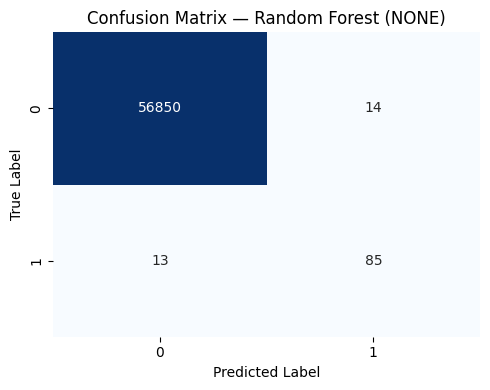

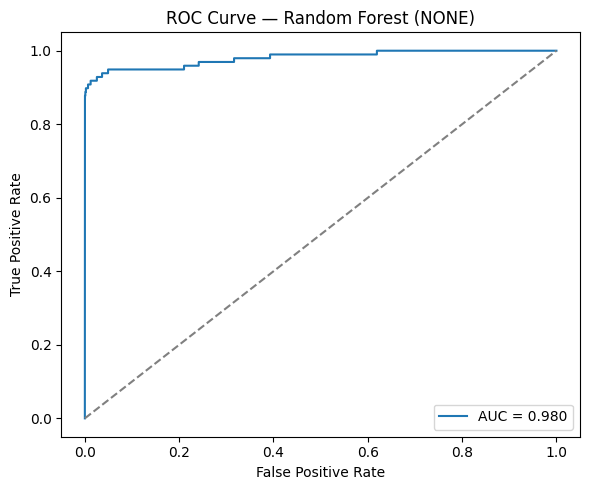

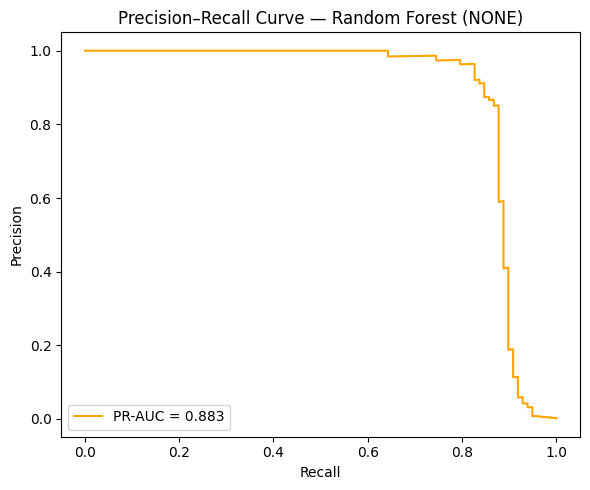

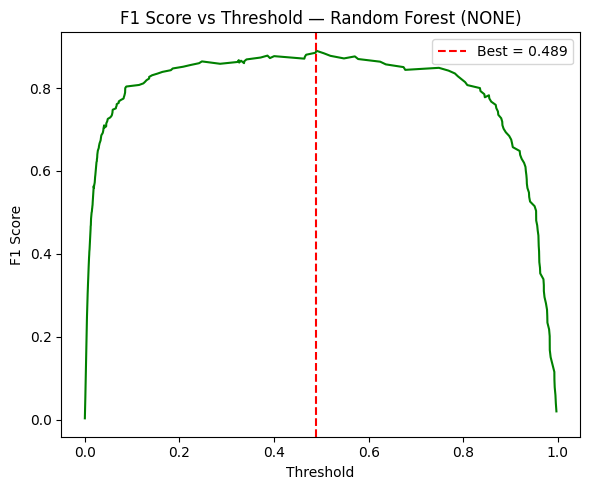

In [ ]:
# ================================================
# 🔹 RUN 1 — NO BALANCING
# ================================================
rf_none_model, rf_none_metrics = train_gpu_rf_balance(X_train, y_train, X_test, y_test, "none")


GPU RANDOM FOREST TRAINING STARTED (CLASS_WEIGHT)
Applying manual class weights...

GPU RANDOM FOREST (cuML) RANDOM SEARCH STARTED

  Iter 1/10: {'n_estimators': 1000, 'max_depth': 12, 'n_bins': 256, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9910
    Fold 2: ROC-AUC = 0.9803
    Fold 3: ROC-AUC = 0.9739
    Fold 4: ROC-AUC = 0.9896
    Fold 5: ROC-AUC = 0.9793
    CV ROC-AUC: 0.9828 ± 0.0065

  Iter 2/10: {'n_estimators': 400, 'max_depth': 16, 'n_bins': 64, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9869
    Fold 2: ROC-AUC = 0.9482
    Fold 3: ROC-AUC = 0.9231
    Fold 4: ROC-AUC = 0.9651
    Fold 5: ROC-AUC = 0.9720
    CV ROC-AUC: 0.9591 ± 0.0218

  Iter 3/10: {'n_estimators': 800, 'max_depth': 16, 'n_bins': 128, 'bootstrap': False, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9891
    Fold 2: ROC-AUC = 0.9743
    Fold 3: ROC-AUC = 0.9669
    Fold 4: ROC-AUC = 0.9871
    Fold 5: ROC-AUC = 0.9745
    CV ROC-AUC: 0.9784 ± 0.

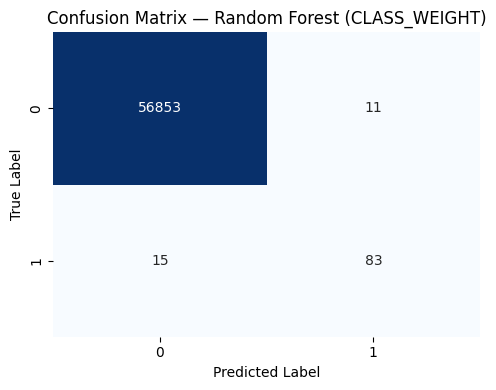

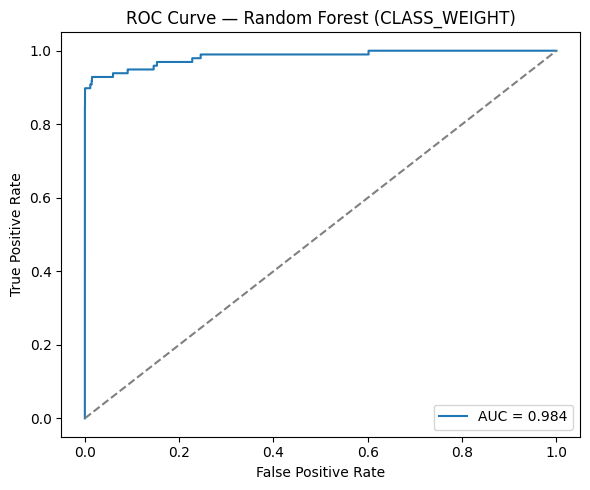

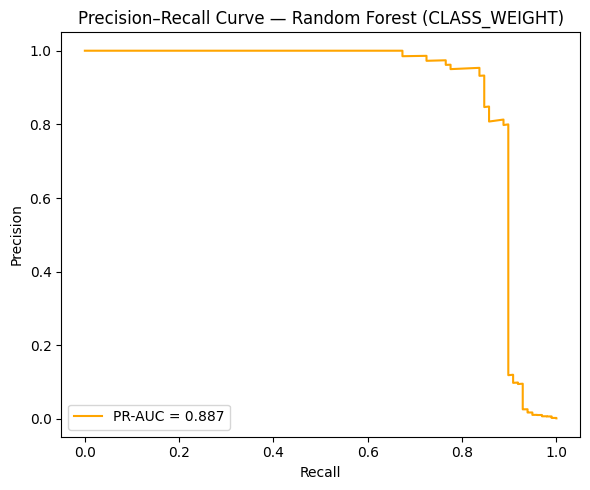

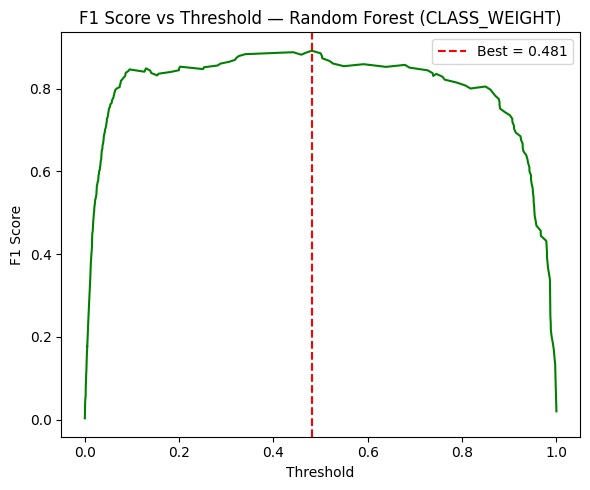

In [ ]:
# ================================================
# 🔹 RUN 2 — CLASS WEIGHT
# ================================================
rf_cw_model, rf_cw_metrics = train_gpu_rf_balance(X_train, y_train, X_test, y_test, "class_weight")


GPU RANDOM FOREST TRAINING STARTED (SMOTE)
Applying SMOTE balancing...

GPU RANDOM FOREST (cuML) RANDOM SEARCH STARTED

  Iter 1/10: {'n_estimators': 1000, 'max_depth': 20, 'n_bins': 128, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 1.0000
    Fold 2: ROC-AUC = 1.0000
    Fold 3: ROC-AUC = 1.0000
    Fold 4: ROC-AUC = 1.0000
    Fold 5: ROC-AUC = 1.0000
    CV ROC-AUC: 1.0000 ± 0.0000

  Iter 2/10: {'n_estimators': 1000, 'max_depth': 20, 'n_bins': 64, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 1.0000
    Fold 2: ROC-AUC = 1.0000
    Fold 3: ROC-AUC = 1.0000
    Fold 4: ROC-AUC = 1.0000
    Fold 5: ROC-AUC = 1.0000
    CV ROC-AUC: 1.0000 ± 0.0000

  Iter 3/10: {'n_estimators': 400, 'max_depth': 12, 'n_bins': 256, 'bootstrap': False, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 1.0000
    Fold 2: ROC-AUC = 1.0000
    Fold 3: ROC-AUC = 1.0000
    Fold 4: ROC-AUC = 1.0000
    Fold 5: ROC-AUC = 1.0000
    CV ROC-AUC: 1.0000 ± 0.0000

  Ite

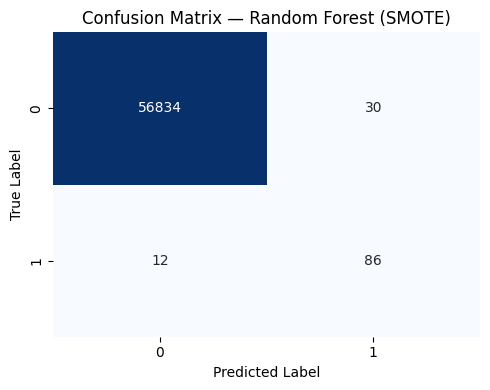

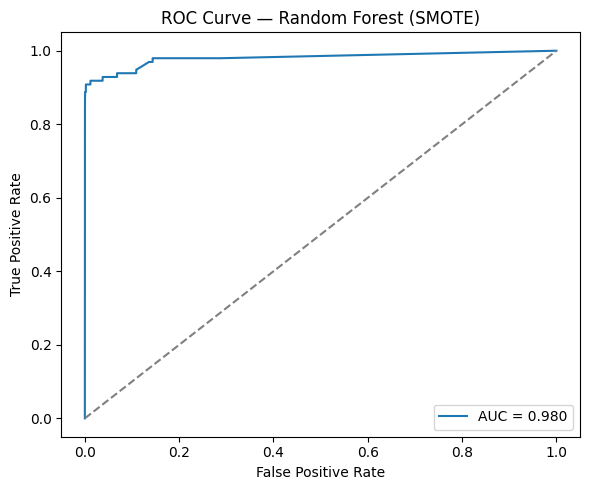

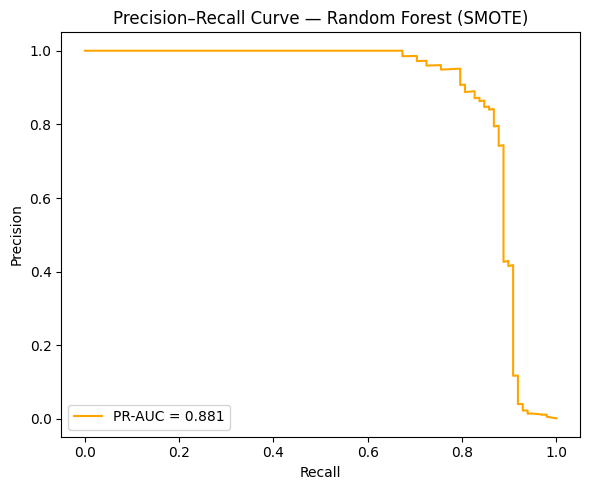

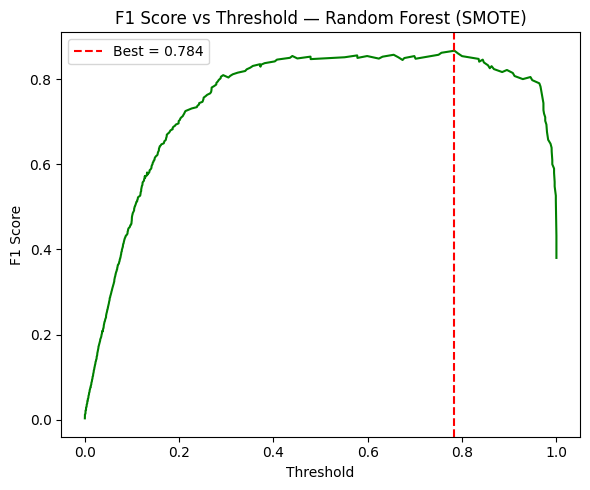

In [ ]:
# ================================================
# 🔹 RUN 3 — SMOTE
# ================================================
rf_smote_model, rf_smote_metrics = train_gpu_rf_balance(X_train, y_train, X_test, y_test, "smote")


GPU RANDOM FOREST TRAINING STARTED (SMOTE_CLASS_WEIGHT)
Applying SMOTE + Class Weight hybrid...

GPU RANDOM FOREST (cuML) RANDOM SEARCH STARTED

  Iter 1/10: {'n_estimators': 400, 'max_depth': 8, 'n_bins': 64, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9994
    Fold 2: ROC-AUC = 0.9994
    Fold 3: ROC-AUC = 0.9993
    Fold 4: ROC-AUC = 0.9993
    Fold 5: ROC-AUC = 0.9993
    CV ROC-AUC: 0.9994 ± 0.0000

  Iter 2/10: {'n_estimators': 800, 'max_depth': 8, 'n_bins': 256, 'bootstrap': True, 'split_criterion': 'gini'}
    Fold 1: ROC-AUC = 0.9994
    Fold 2: ROC-AUC = 0.9993
    Fold 3: ROC-AUC = 0.9994
    Fold 4: ROC-AUC = 0.9993
    Fold 5: ROC-AUC = 0.9993
    CV ROC-AUC: 0.9993 ± 0.0000

  Iter 3/10: {'n_estimators': 800, 'max_depth': 24, 'n_bins': 64, 'bootstrap': False, 'split_criterion': 'entropy'}
    Fold 1: ROC-AUC = 1.0000
    Fold 2: ROC-AUC = 1.0000
    Fold 3: ROC-AUC = 1.0000
    Fold 4: ROC-AUC = 1.0000
    Fold 5: ROC-AUC = 1.0000
    CV ROC-AUC:

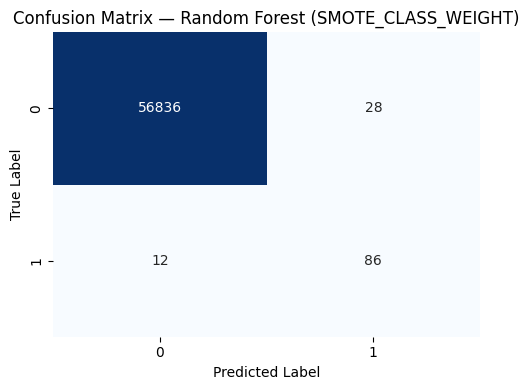

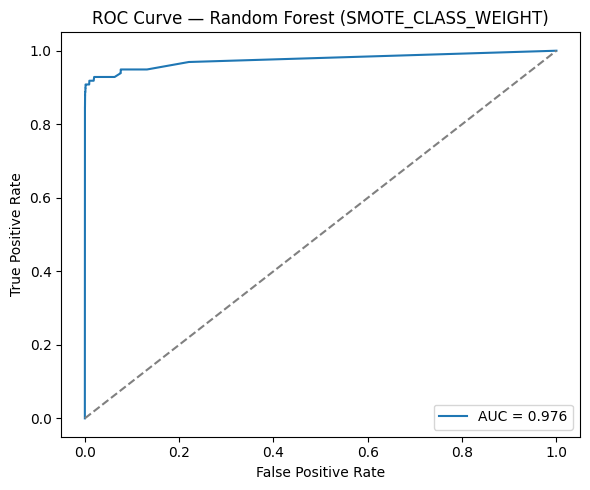

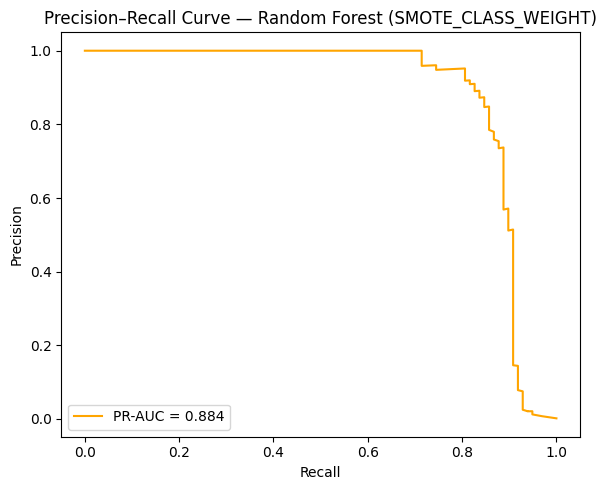

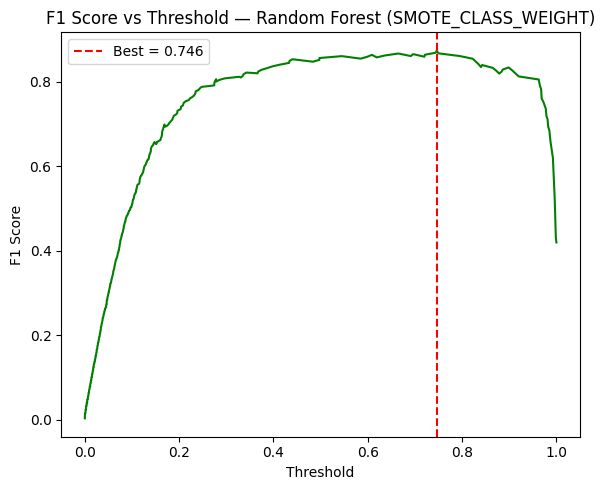

In [ ]:
# ================================================
# 🔹 RUN 4 — SMOTE + CLASS_WEIGHT
# ================================================
rf_hybrid_model, rf_hybrid_metrics = train_gpu_rf_balance(X_train, y_train, X_test, y_test, "smote_class_weight")

In [ ]:
# =========================================================
# Results Summary
# =========================================================
results_df = pd.DataFrame([
    {"Model": "RF — None", "ROC-AUC": rf_none_metrics["roc_auc"], "PR-AUC": rf_none_metrics["pr_auc"], "Best Params": rf_none_metrics["best_params"]},
    {"Model": "RF — Class Weight", "ROC-AUC": rf_cw_metrics["roc_auc"], "PR-AUC": rf_cw_metrics["pr_auc"], "Best Params": rf_cw_metrics["best_params"]},
    {"Model": "RF — SMOTE", "ROC-AUC": rf_smote_metrics["roc_auc"], "PR-AUC": rf_smote_metrics["pr_auc"], "Best Params": rf_smote_metrics["best_params"]},
    {"Model": "RF — SMOTE + Class Weight", "ROC-AUC": rf_hybrid_metrics["roc_auc"], "PR-AUC": rf_hybrid_metrics["pr_auc"], "Best Params": rf_hybrid_metrics["best_params"]}
])

print("\n================== GPU RANDOM FOREST RESULTS ==================")
print(results_df.to_string(index=False))


================== GPU RANDOM FOREST RESULTS ==================
                    Model  ROC-AUC   PR-AUC                                                                                             Best Params
                RF — None 0.980458 0.882687  {'n_estimators': 800, 'max_depth': 8, 'n_bins': 256, 'bootstrap': False, 'split_criterion': 'entropy'}
        RF — Class Weight 0.984004 0.886736  {'n_estimators': 600, 'max_depth': 12, 'n_bins': 64, 'bootstrap': False, 'split_criterion': 'entropy'}
               RF — SMOTE 0.980497 0.880761 {'n_estimators': 800, 'max_depth': 20, 'n_bins': 256, 'bootstrap': False, 'split_criterion': 'entropy'}
RF — SMOTE + Class Weight 0.975871 0.884452  {'n_estimators': 800, 'max_depth': 24, 'n_bins': 64, 'bootstrap': False, 'split_criterion': 'entropy'}
